In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

1.Load data

In [58]:
import pandas as pd
df = pd.read_csv("Nat_Gas.csv")  # replace with your path

# Clean column names
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={"dates": "date", "prices": "price"}, inplace=True)

# Convert 'date' column to datetime (let pandas infer format)
df["date"] = pd.to_datetime(df["date"], infer_datetime_format=True)

# Sort by date
df = df.sort_values("date").reset_index(drop=True)

# Quick check
print(df.head())
print(df.dtypes)


        date  price
0 2020-10-31   10.1
1 2020-11-30   10.3
2 2020-12-31   11.0
3 2021-01-31   10.9
4 2021-02-28   10.9
date     datetime64[ns]
price           float64
dtype: object


/tmp/ipykernel_16745/531706653.py:9: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["date"] = pd.to_datetime(df["date"], infer_datetime_format=True)
/tmp/ipykernel_16745/531706653.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], infer_datetime_format=True)


Visualize historical data

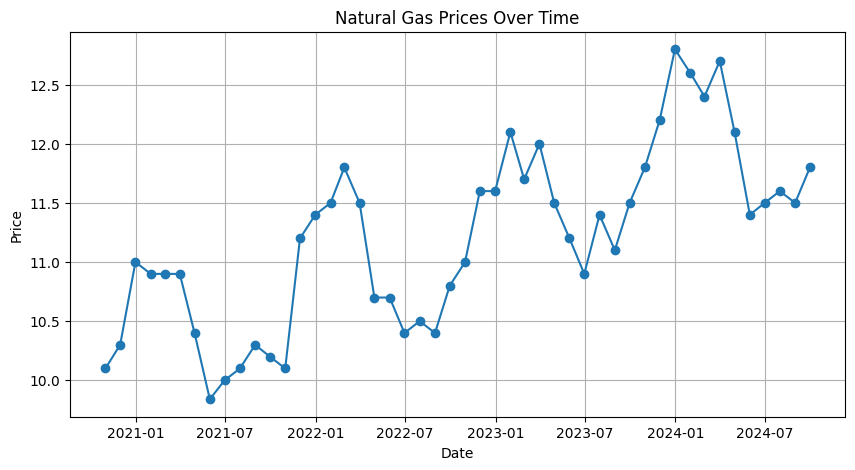

In [59]:
plt.figure(figsize=(10,5))
plt.plot(df["date"], df["price"], marker='o')
plt.title("Natural Gas Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


Feature Engineering

In [60]:
# Time trend: number of days since first date
df["days"] = (df["date"] - df["date"].min()).dt.days

# Seasonality: monthly cycle using sin/cos
df["month"] = df["date"].dt.month
df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)


Train model

In [61]:
X = df[["days", "sin_month", "cos_month"]]
y = df["price"]

model = LinearRegression()
model.fit(X, y)


LinearRegression()

Price prediction function

In [62]:
def get_price(input_date):
    input_date = pd.to_datetime(input_date)

    days = (input_date - df["date"].min()).days
    month = input_date.month
    sin_month = np.sin(2 * np.pi * month / 12)
    cos_month = np.cos(2 * np.pi * month / 12)

    # Pass as DataFrame with column names
    X_pred = pd.DataFrame([[days, sin_month, cos_month]],
                          columns=["days", "sin_month", "cos_month"])

    return float(model.predict(X_pred)[0])

Extrapolate 1 year into future

In [63]:
future_dates = pd.date_range(
    start=df["date"].max() + pd.DateOffset(days=1),
    end=df["date"].max() + pd.DateOffset(years=1),
    freq='ME'  # month-end
)

future_prices = [get_price(d) for d in future_dates]

Visualize historical + forecast

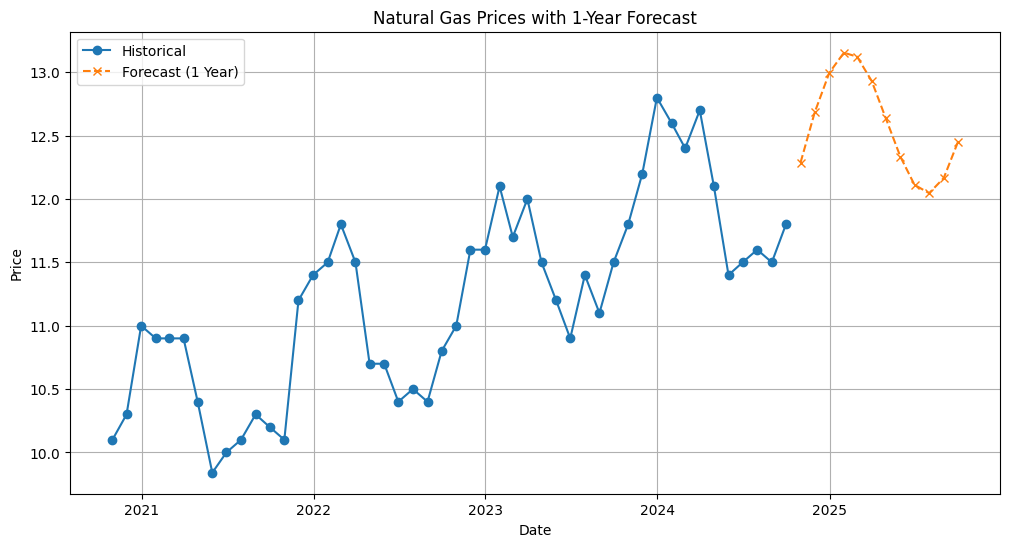

In [64]:
plt.figure(figsize=(12,6))

# Historical prices
plt.plot(df["date"], df["price"], label="Historical", marker='o')

# Forecast prices
plt.plot(future_dates, future_prices, label="Forecast (1 Year)", linestyle='--', marker='x')

plt.title("Natural Gas Prices with 1-Year Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()



Test Prediction Function

In [65]:
print("Estimated price on 2023-06-15:", get_price("2023-06-15"))  # past date
print("Estimated price on 2025-01-15:", get_price("2025-01-15"))  # future date

Estimated price on 2023-06-15: 10.992896189599906
Estimated price on 2025-01-15: 13.130106902700328
